<a href="https://colab.research.google.com/github/Schimidel/UGRH-s-Precipita-oeTemperatura/blob/main/Atividade_Wavelets_Temperatura.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


In [1]:
!pip install xarray scipy pycwt netcdf4 statsmodels


In [2]:
# Importação das bibliotecas principais
import xarray as xr
import numpy as np
from scipy import stats
import pandas as pd
import matplotlib.pyplot as plt
import os


In [3]:
# Carregamento dos dados NetCDF de Temperatura (Compatível com Colab e Local)
paths = {
    'NOAA': ['./Dados/temp_NOAA.nc', 'drive/MyDrive/Precipitacao_e_Indices/temp_NOAA.nc'],
    'NCEP': ['./Dados/temp_NCEP.nc', 'drive/MyDrive/Precipitacao_e_Indices/temp_NCEP.nc']
}

def load_dataset(name):
    for path in paths[name]:
        if os.path.exists(path):
            print(f'Carregando {name} de: {path}')
            return xr.open_dataset(path)
    raise FileNotFoundError(f'Não foi possível encontrar o arquivo NetCDF de {name}')

temp_NOAA = load_dataset('NOAA').air
temp_NCEP = load_dataset('NCEP').air


Carregando NOAA de: ./Dados/temp_NOAA.nc
Carregando NCEP de: ./Dados/temp_NCEP.nc


In [4]:
# Cálculo das médias espaciais para a área de interesse
mean_NOAA = temp_NOAA.mean(dim=['latitude', 'longitude'])
mean_NCEP = temp_NCEP.mean(dim=['lat', 'lon'])


In [5]:
# Cálculo das anomalias mensais (com base na climatologia de 1981 a 2011)
anom_NCEP = mean_NCEP - mean_NCEP.sel(time=slice('1981', '2011')).mean(dim='time')
anom_NOAA = mean_NOAA - mean_NOAA.sel(time=slice('1981', '2011')).mean(dim='time')


In [6]:
# Conversão dos dados de anomalia para DataFrames do Pandas
df_NCEP = anom_NCEP.to_dataframe()
df_NCEP.index = df_NCEP.index.strftime('%Y-%m')
df_NCEP = df_NCEP.reset_index()

df_NOAA = anom_NOAA.to_dataframe()
df_NOAA.index = df_NOAA.index.strftime('%Y-%m')
df_NOAA = df_NOAA.reset_index()


In [7]:
# Exibição das informações estruturais dos DataFrames
df_NCEP.info()
print('-'*50)
df_NOAA.info()


<class 'pandas.DataFrame'>
RangeIndex: 620 entries, 0 to 619
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   time    620 non-null    str    
 1   air     620 non-null    float32
dtypes: float32(1), str(1)
memory usage: 7.4 KB
--------------------------------------------------
<class 'pandas.DataFrame'>
RangeIndex: 620 entries, 0 to 619
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   time    620 non-null    str    
 1   air     620 non-null    float32
dtypes: float32(1), str(1)
memory usage: 7.4 KB


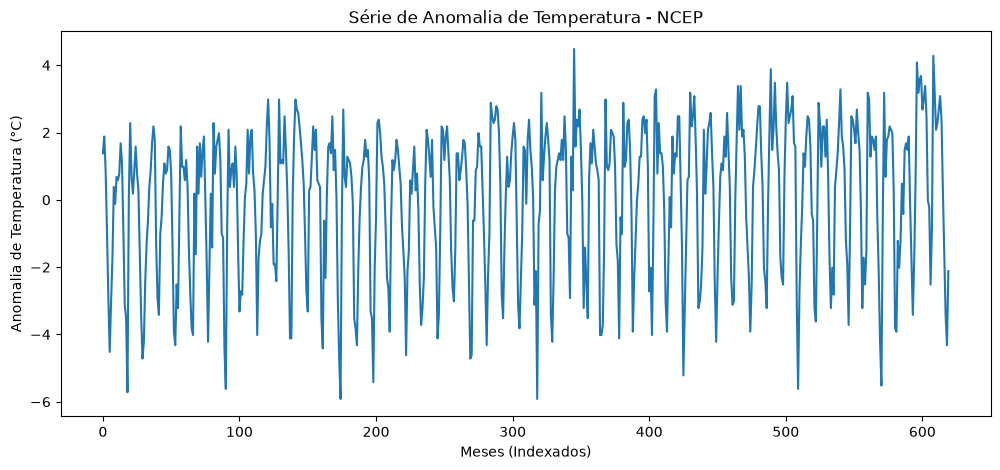

In [8]:
# Plotagem inicial da anomalia de temperatura do NCEP
fig, ax = plt.subplots(figsize=(12, 5))
df_NCEP['air'].plot(ax=ax)
plt.title('Série de Anomalia de Temperatura - NCEP')
plt.xlabel('Meses (Indexados)')
plt.ylabel('Anomalia de Temperatura (°C)')
plt.show()


In [9]:
# Função auxiliar para realizar a análise wavelet completa e plotar os resultados
def plot_wavelet_analysis(df, val_col, title, label, units, date_col='time',
                           periodo_interesse=[0, 1], significance_level=0.75,
                           save_filename=None, figsize_overall=(11, 8)):
    import numpy as np
    import matplotlib.pyplot as plt
    import pycwt as wavelet
    from pycwt.helpers import find
    
    # 1. Preparar os dados
    dat = np.array(df[val_col])
    dt = 1/12  # em anos (dado mensal)
    t0 = 0
    N = dat.size
    
    # Tentar construir o eixo de anos baseado nas datas reais
    try:
        if date_col in df.columns:
            start_year = int(df[date_col].iloc[0].split('-')[0])
        else:
            start_year = df.index[0].year
        t = np.arange(start_year, start_year + N * dt, dt)[:N]
        end_year = t[-1] + dt
    except Exception:
        t = np.arange(0, N) * dt + t0
        start_year = t.min()
        end_year = t.max()
        
    # 2. Remover a tendência linear e normalizar
    p = np.polyfit(t - t.min(), dat, 1)
    dat_notrend = dat - np.polyval(p, t - t.min())
    std = dat_notrend.std()
    var = std ** 2
    dat_norm = dat_notrend / std
    
    # 3. Parâmetros da wavelet
    mother = wavelet.Morlet(6)
    s0 = 2 * dt
    dj = 1 / 12
    J = 8 / dj
    alpha, _, _ = wavelet.ar1(dat)  # Autocorrelação Lag-1 para ruído vermelho
    
    # 4. Transformada Wavelet
    wave, scales, freqs, coi, fft, fftfreqs = wavelet.cwt(dat_norm, dt, dj, s0, J, mother)
    iwave = wavelet.icwt(wave, scales, dt, dj, mother) * std
    
    power = (np.abs(wave)) ** 2
    fft_power = np.abs(fft) ** 2
    period = 1 / freqs
    
    # 5. Significância e espectros teóricos
    signif, fft_theor = wavelet.significance(1.0, dt, scales, 0, alpha,
                                             significance_level=significance_level,
                                             wavelet=mother)
    sig95 = np.ones([1, N]) * signif[:, None]
    sig95 = power / sig95
    
    # Espectro Wavelet Global
    glbl_power = power.mean(axis=1)
    dof = N - scales
    glbl_signif, tmp = wavelet.significance(var, dt, scales, 1, alpha,
                                            significance_level=significance_level,
                                            dof=dof, wavelet=mother)
                                            
    # Média da escala
    sel = find((period >= periodo_interesse[0]) & (period <= periodo_interesse[1]))
    Cdelta = mother.cdelta
    scale_avg = (scales * np.ones((N, 1))).transpose()
    scale_avg = power / scale_avg
    scale_avg = var * dj * dt / Cdelta * scale_avg[sel, :].sum(axis=0)
    scale_avg_signif, tmp = wavelet.significance(var, dt, scales, 2, alpha,
                                                 significance_level=significance_level,
                                                 dof=[scales[sel[0]], scales[sel[-1]]],
                                                 wavelet=mother)
                                                 
    # 6. Plotagem
    fig = plt.figure(figsize=figsize_overall)
    
    # Sub-gráfico a) Série temporal original e wavelet inversa
    ax = plt.axes([0.1, 0.75, 0.65, 0.2])
    ax.plot(t, iwave, '-', linewidth=1, color=[0.5, 0.5, 0.5], label='Wavelet Inversa')
    ax.plot(t, dat, 'k', linewidth=1.5, label='Original')
    ax.set_title(f'a) {title}', fontsize=10)
    ax.set_ylabel(f'{label} [{units}]', fontsize=9)
    ax.set_xlim([start_year, end_year])
    
    # Sub-gráfico b) Espectro de potência wavelet
    bx = plt.axes([0.1, 0.39, 0.65, 0.28], sharex=ax)
    levels = [0.0625, 0.125, 0.25, 0.5, 1, 2, 4, 8, 16, 32]
    bx.contourf(t, np.log2(period), np.log2(power), levels=np.log2(levels), extend='both', cmap=plt.cm.rainbow)
    extent = [t.min(), t.max(), np.log2(period.min()), np.log2(period.max())]
    bx.contour(t, np.log2(period), sig95, levels=[-99, 1], colors='k', linewidths=2, extent=extent)
    bx.fill(np.concatenate([t, t[-1:] + dt, t[-1:] + dt, t[:1] - dt, t[:1] - dt]),
            np.concatenate([np.log2(coi), [1e-9], np.log2(period[-1:]), np.log2(period[-1:]), [1e-9]]),
            'k', alpha=0.3, hatch='x')
    bx.set_title(f'b) Espectro de Potência Wavelet de {label} ({mother.name})', fontsize=10)
    bx.set_ylabel('Período (Anos)', fontsize=9)
    bx.set_xlim([start_year, end_year])
    
    Yticks = 2 ** np.arange(np.ceil(np.log2(period.min())), np.ceil(np.log2(period.max())))
    bx.set_yticks(np.log2(Yticks))
    bx.set_yticklabels(Yticks)
    
    # Sub-gráfico c) Espectro wavelet global e Fourier
    cx = plt.axes([0.77, 0.39, 0.2, 0.28], sharey=bx)
    cx.plot(glbl_signif, np.log2(period), 'k--')
    cx.plot(var * fft_theor, np.log2(period), '--', color='#cccccc')
    cx.plot(var * fft_power, np.log2(1./fftfreqs), '-', color='#cccccc', linewidth=1.)
    cx.plot(var * glbl_power, np.log2(period), 'k-', linewidth=1.5)
    cx.set_title('c) Espectro Global', fontsize=10)
    cx.set_xlabel(f'Poder [({units})^2]', fontsize=9)
    cx.set_ylim(np.log2([period.min(), period.max()]))
    cx.set_yticks(np.log2(Yticks))
    cx.set_yticklabels(Yticks)
    plt.setp(cx.get_yticklabels(), visible=False)
    
    # Sub-gráfico d) Espectro de ondas médias da escala (variância média)
    dx = plt.axes([0.1, 0.12, 0.65, 0.2], sharex=ax)
    dx.axhline(scale_avg_signif, color='k', linestyle='--', linewidth=1.)
    dx.plot(t, scale_avg, 'k-', linewidth=1.5)
    dx.set_title(f'd) {periodo_interesse[0]}--{periodo_interesse[1]} Anos (variância média da escala)', fontsize=10)
    dx.set_xlabel('Tempo (Ano)', fontsize=9)
    dx.set_ylabel(f'Variância Média [{units}]', fontsize=9)
    dx.set_xlim([start_year, end_year])
    
    if save_filename:
        plt.savefig(save_filename, dpi=600, bbox_inches='tight')
    plt.show()



# Análise de Wavelets - Dados NCEP (Temperatura)
Realizaremos a análise de wavelets tanto para a série de anomalia de temperatura bruta quanto para a série com remoção do ciclo sazonal.


c:\Users\gabri\Downloads\UGRH\.venv\Lib\site-packages\matplotlib\cbook.py:1810: ComplexWarning: Casting complex values to real discards the imaginary part
  return math.isfinite(val)
c:\Users\gabri\Downloads\UGRH\.venv\Lib\site-packages\matplotlib\cbook.py:1407: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.asanyarray(x, float)


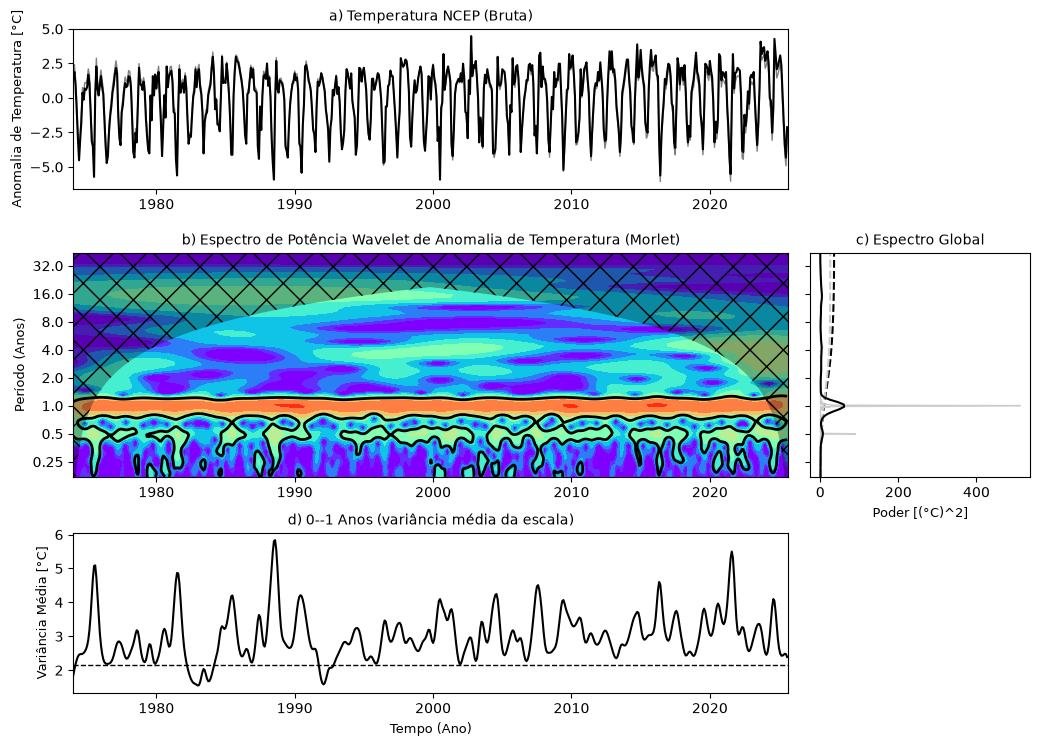

In [10]:
# Análise Wavelet: Anomalia Bruta (NCEP)
plot_wavelet_analysis(
    df=df_NCEP,
    val_col='air',
    title='Temperatura NCEP (Bruta)',
    label='Anomalia de Temperatura',
    units='°C',
    save_filename='Wavelets_Temp_NCEP_Bruta.png'
)


In [11]:
# Decomposição Sazonal (NCEP)
from statsmodels.tsa.seasonal import seasonal_decompose
decomp_NCEP = seasonal_decompose(df_NCEP['air'], model='additive', period=12, two_sided=True)
df_NCEP['no_season'] = df_NCEP['air'] - decomp_NCEP.seasonal


c:\Users\gabri\Downloads\UGRH\.venv\Lib\site-packages\matplotlib\cbook.py:1810: ComplexWarning: Casting complex values to real discards the imaginary part
  return math.isfinite(val)
c:\Users\gabri\Downloads\UGRH\.venv\Lib\site-packages\matplotlib\cbook.py:1407: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.asanyarray(x, float)


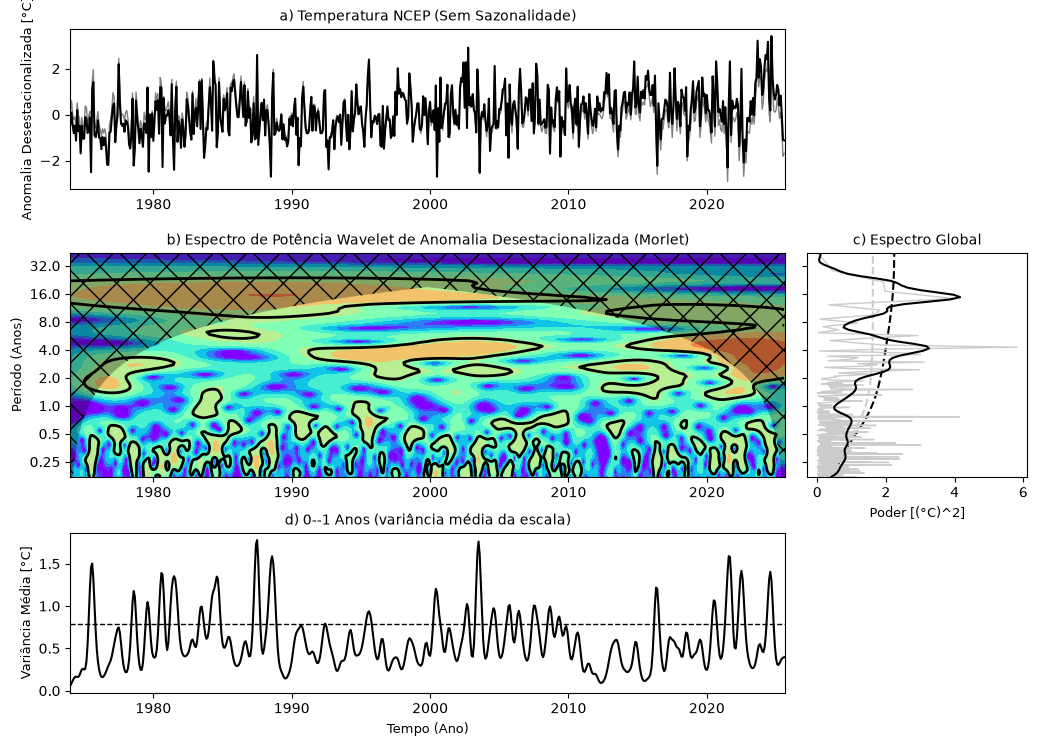

In [12]:
# Análise Wavelet: Sem Ciclo Sazonal (NCEP)
plot_wavelet_analysis(
    df=df_NCEP,
    val_col='no_season',
    title='Temperatura NCEP (Sem Sazonalidade)',
    label='Anomalia Desestacionalizada',
    units='°C',
    save_filename='Wavelets_Temp_NCEP_SemSazonalidade.png'
)


# Análise de Wavelets - Dados NOAA (Temperatura)
Agora, estendemos a análise wavelet para o conjunto de dados da NOAA.


c:\Users\gabri\Downloads\UGRH\.venv\Lib\site-packages\matplotlib\cbook.py:1810: ComplexWarning: Casting complex values to real discards the imaginary part
  return math.isfinite(val)
c:\Users\gabri\Downloads\UGRH\.venv\Lib\site-packages\matplotlib\cbook.py:1407: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.asanyarray(x, float)


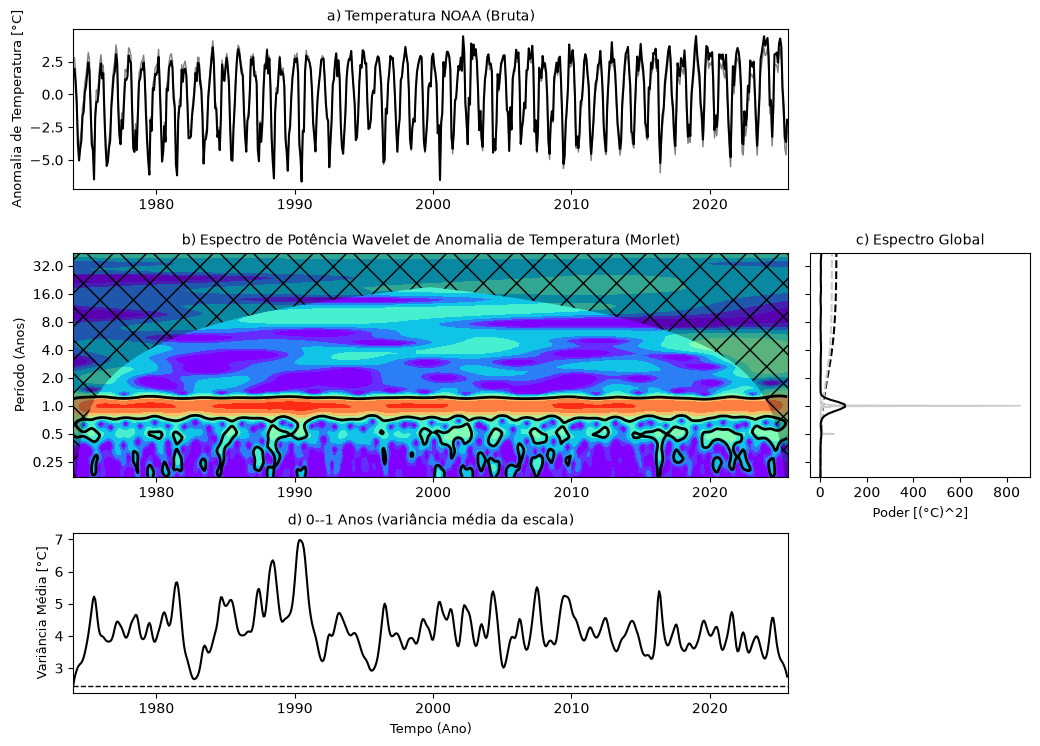

In [13]:
# Análise Wavelet: Anomalia Bruta (NOAA)
plot_wavelet_analysis(
    df=df_NOAA,
    val_col='air',
    title='Temperatura NOAA (Bruta)',
    label='Anomalia de Temperatura',
    units='°C',
    save_filename='Wavelets_Temp_NOAA_Bruta.png'
)


In [14]:
# Decomposição Sazonal (NOAA)
from statsmodels.tsa.seasonal import seasonal_decompose
decomp_NOAA = seasonal_decompose(df_NOAA['air'], model='additive', period=12, two_sided=True)
df_NOAA['no_season'] = df_NOAA['air'] - decomp_NOAA.seasonal


c:\Users\gabri\Downloads\UGRH\.venv\Lib\site-packages\matplotlib\cbook.py:1810: ComplexWarning: Casting complex values to real discards the imaginary part
  return math.isfinite(val)
c:\Users\gabri\Downloads\UGRH\.venv\Lib\site-packages\matplotlib\cbook.py:1407: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.asanyarray(x, float)


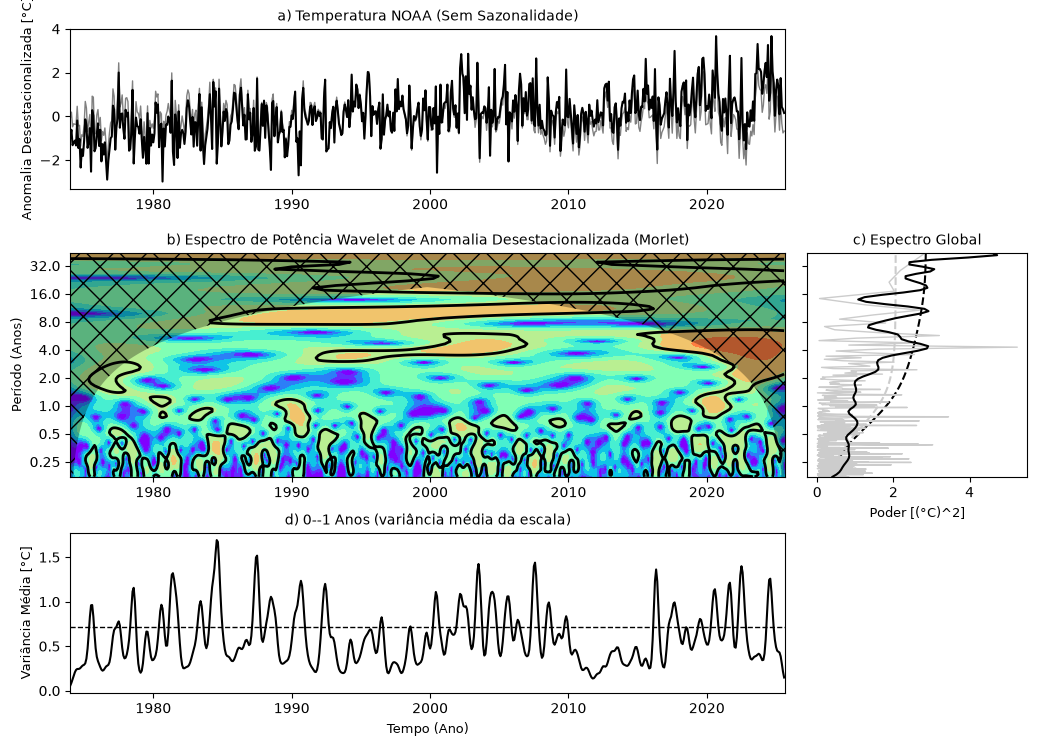

In [15]:
# Análise Wavelet: Sem Ciclo Sazonal (NOAA)
plot_wavelet_analysis(
    df=df_NOAA,
    val_col='no_season',
    title='Temperatura NOAA (Sem Sazonalidade)',
    label='Anomalia Desestacionalizada',
    units='°C',
    save_filename='Wavelets_Temp_NOAA_SemSazonalidade.png'
)
